In [1]:
from homicsx import(
    GeometryInput, 
    PhysicalTags, 
    MeshSettings, 
    LinearElasticIsotropic, 
    MaterialAssignment, 
    ProblemSettings
)
from homicsx.stochastic import (
    sweep_volume_fraction_linear, 
    sweep_stiffness_contrast_linear,
)

import numpy as np

Preparing geometry input for 2D mono-disperse unit-cell geometry with spherical inclusions

In [2]:
geometry_input = GeometryInput(
    dim=2,
    dispersion="mono",
    volume_fraction=0.2,
    num_particles=30,
    clearance=0.015,
    domain_size=(1, 1),
    shape="circle",
)

Preparing physical tagging convention and mesh settings

In [3]:
physical_tags = PhysicalTags()

mesh_settings = MeshSettings(
    min_size=0.025,
    max_size=0.035,
    physical_tags=physical_tags,
)

Defining the material assignment

In [4]:
E_mat = 1.0
nu_mat = 0.3
mat_matrix = LinearElasticIsotropic(young_modulus=E_mat, poisson_ratio=nu_mat)

E_inc = 100.0
nu_inc = 0.3
mat_particle = LinearElasticIsotropic(young_modulus=E_inc, poisson_ratio=nu_inc)

material_assignment = MaterialAssignment(
    materials_by_phase={
        0: mat_matrix,
        1: mat_particle,
    }
)

Preparing the FEM solver settings

In [5]:
fem_settings = ProblemSettings(
    dim = geometry_input.dim,
    kinematics='small_strain',
    two_dimensional_formulation='plane_strain',
    element_family='Lagrange',
    element_degree=1,
    petsc_options = {
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    },
)

Performing volume fraction sweep

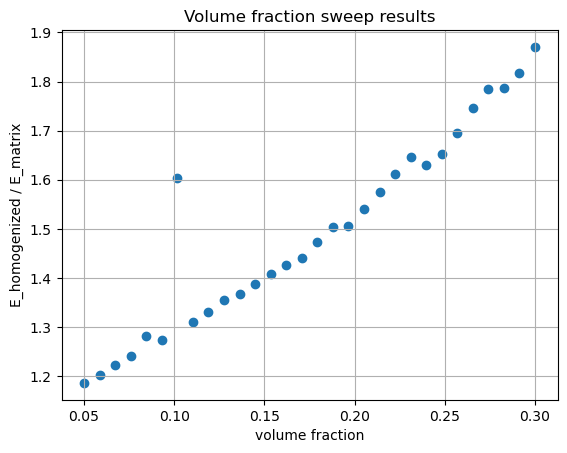

In [6]:
sweep_list = np.linspace(0.05, 0.3, 30)
ensemble_result = sweep_volume_fraction_linear(
    sweep_list=sweep_list,
    homogenization_mode='partial',
    geometry_settings=geometry_input,
    mesh_settings=mesh_settings,
    physical_tags=physical_tags,
    material_assignment=material_assignment,
    fem_settings=fem_settings,
)

Performing stiffness contrast sweep

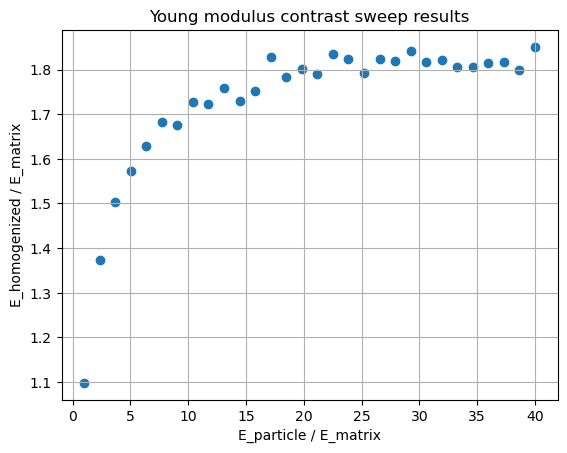

In [7]:
sweep_list = np.linspace(1, 40, 30)
ensemble_result = sweep_stiffness_contrast_linear(
    sweep_list=sweep_list,
    homogenization_mode='partial',
    geometry_settings=geometry_input,
    mesh_settings=mesh_settings,
    physical_tags=physical_tags,
    material_assignment=material_assignment,
    fem_settings=fem_settings,
)